## Setup

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS,
                                 species_label, target_config)

TARGET     = "pion"            # "pion" | "photon"
COMPARISON = "architecture"        # "architecture" | "features"
cfg = target_config(TARGET)

TRACKS_PATH = PROJECT_ROOT / "prepared" / "prepared-mc" / "test_tracks.pkl"
with open(TRACKS_PATH, "rb") as f:
    tracks = pickle.load(f)
species   = np.array([species_label(t) for t in tracks])
is_signal = np.array([cfg['is_signal'](t) for t in tracks])

PRED_DIR = PROJECT_ROOT / "predictions" / "predictions-mc"

if COMPARISON == "architecture":
    MODELS = {
        "CNN":    PRED_DIR / f"cnn_dEdX_seq{cfg['suffix']}.pkl",
        "MLP":    PRED_DIR / f"mlp_summary_base4{cfg['suffix']}.pkl",
        "Hybrid": PRED_DIR / f"hybrid_cnn_mlp_base4{cfg['suffix']}.pkl",
    }
    SUBTITLE = "identical inputs: the four original summary features"
else:
    MODELS = {
        "Hybrid base4": PRED_DIR / f"hybrid_cnn_mlp_base4{cfg['suffix']}.pkl",
        "Hybrid all8":  PRED_DIR / f"hybrid_cnn_mlp_all8{cfg['suffix']}.pkl",
    }
    SUBTITLE = "same architecture, with and without the provenance features"

for name, path in MODELS.items():
    if not path.exists():
        raise SystemExit(f"missing: {path}")

OBS_HD = [('track_score','track score',(0,1)),
          ('dEdX_median','median dE/dx [MeV/cm]',(0,6)),
          ('track_length','track length [cm]',(0,100)),
          ('track_chi2/ndof_proton','chi2/ndof (proton)',(0,100)),
          ('n_hits','n hits',(0,300)),
          ('hit_density','hit density',(0,4))]


def _hit_density(t):
    tl = float(t['track_length'])
    return float(t['n_hits_collection']) / tl if tl > 0 else np.nan


OBSVALS = {}
for key, _, _ in OBS_HD:
    OBSVALS[key] = (np.array([_hit_density(t) for t in tracks]) if key == 'hit_density'
                    else np.array([float(t[key]) for t in tracks]))

ts = OBSVALS['track_score']

PLOTS_DIR = PROJECT_ROOT / "plots" / "contamination-study" / TARGET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"{len(tracks):,} PFOs | target {cfg['signal_name']} "
      f"({is_signal.sum():,}) | main background {cfg['main_bkg']} "
      f"({(species == cfg['main_bkg']).sum():,})")
print(f"comparison: {COMPARISON} — {SUBTITLE}")
print(f"models: {list(MODELS)}")

126,817 PFOs | target $\pi^{\pm}$ (22,347) | main background $\gamma$ (19,753)
comparison: architecture — identical inputs: the four original summary features
models: ['CNN', 'MLP', 'Hybrid']


## Confused photons

CNN: 1,708 confused $\gamma$ (of 19,753) = 4.5% of the tagged sample


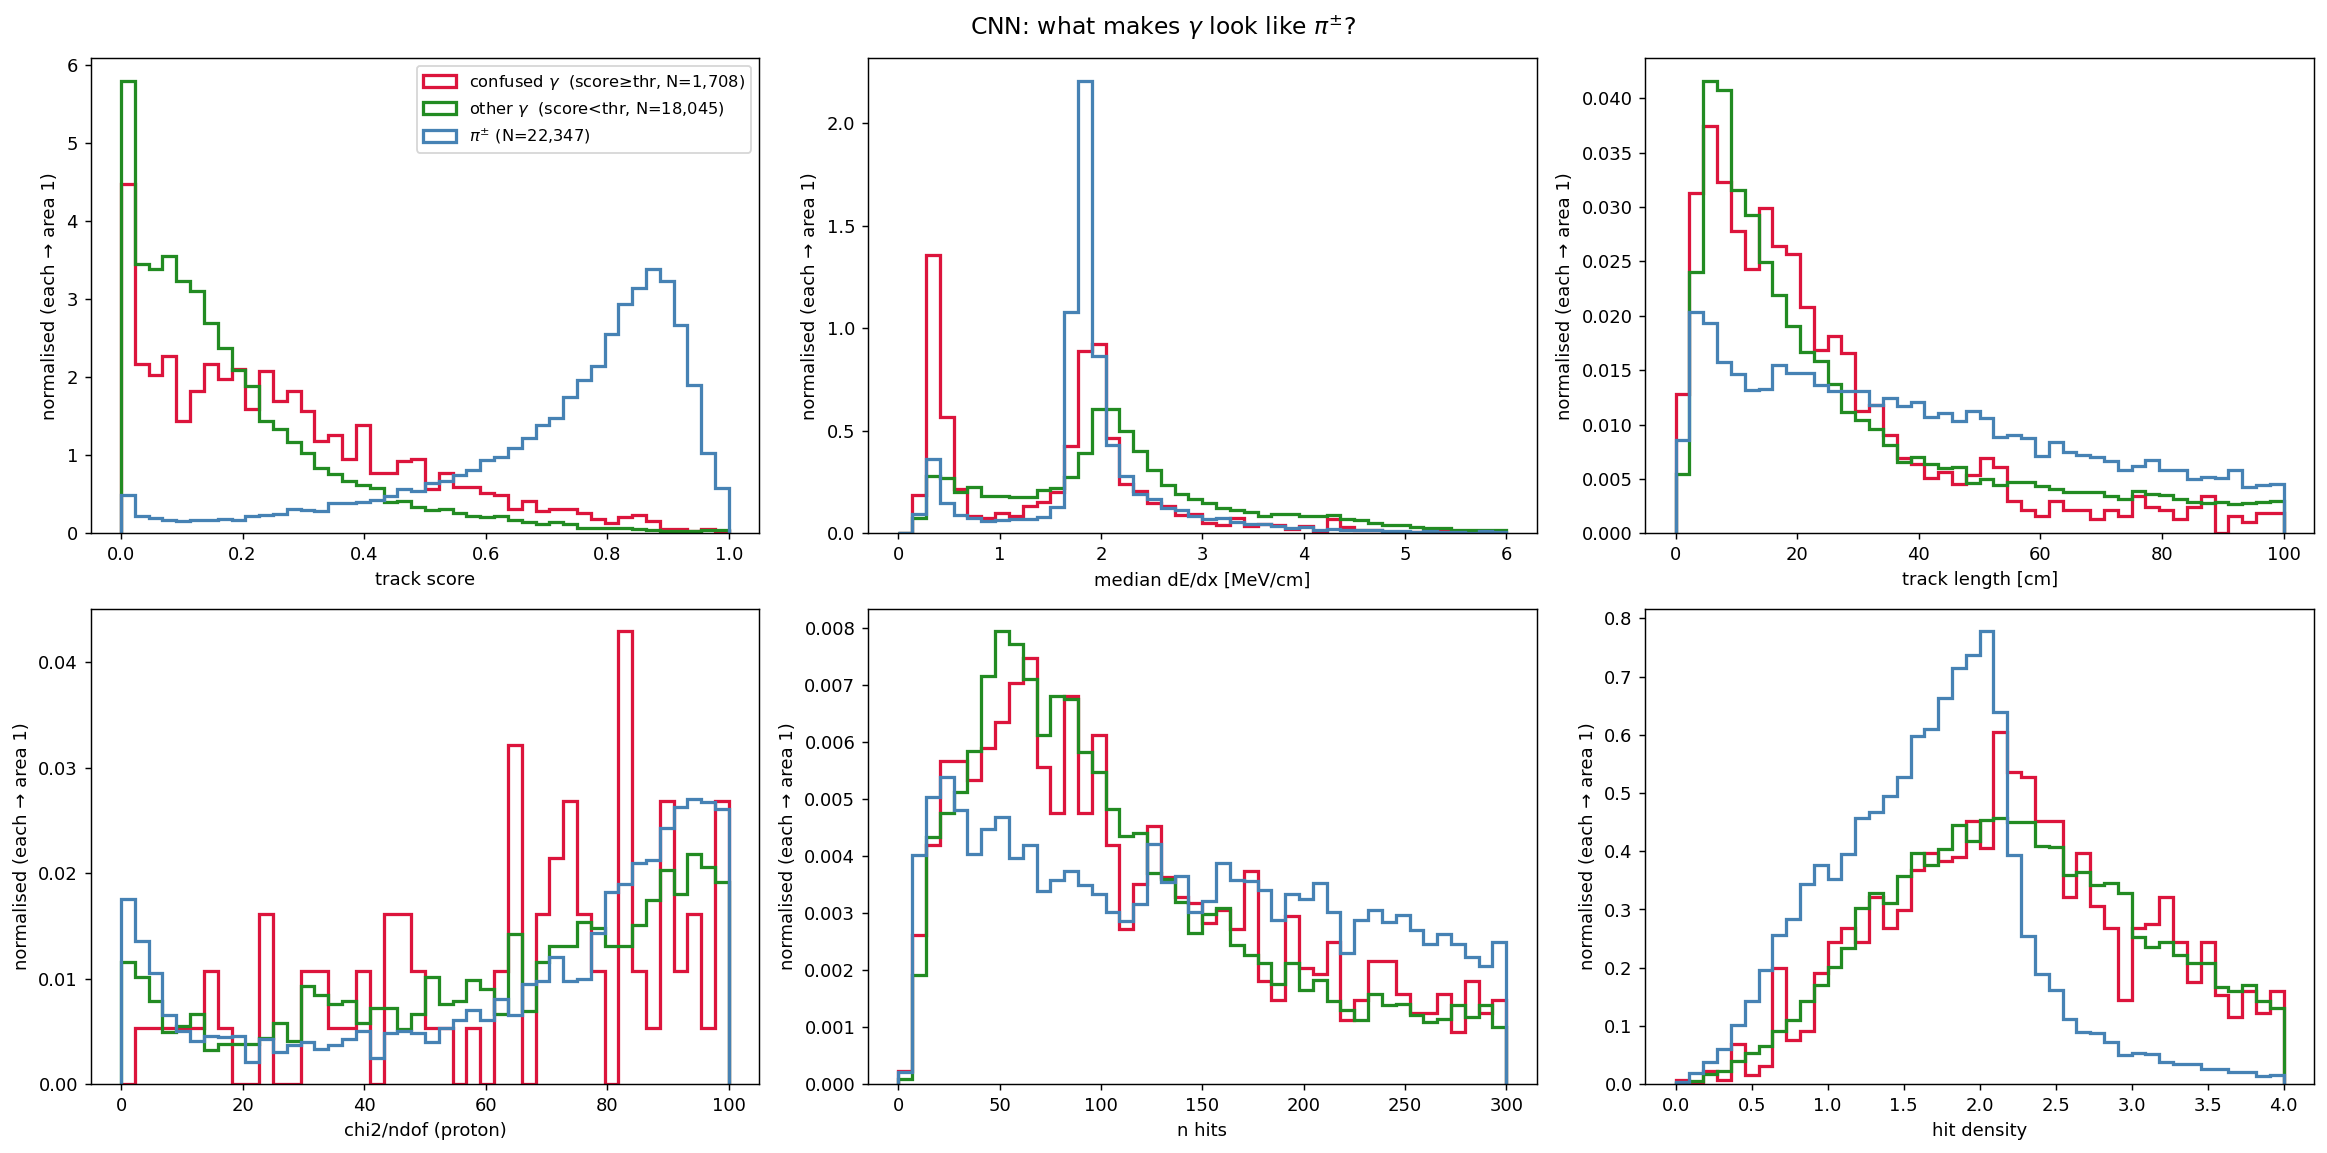

Saved /home/pemb7173/PDSP-pion-classification/plots/contamination-study/pion/confused_CNN_architecture_pion.pdf

MLP: 2,446 confused $\gamma$ (of 19,753) = 5.4% of the tagged sample


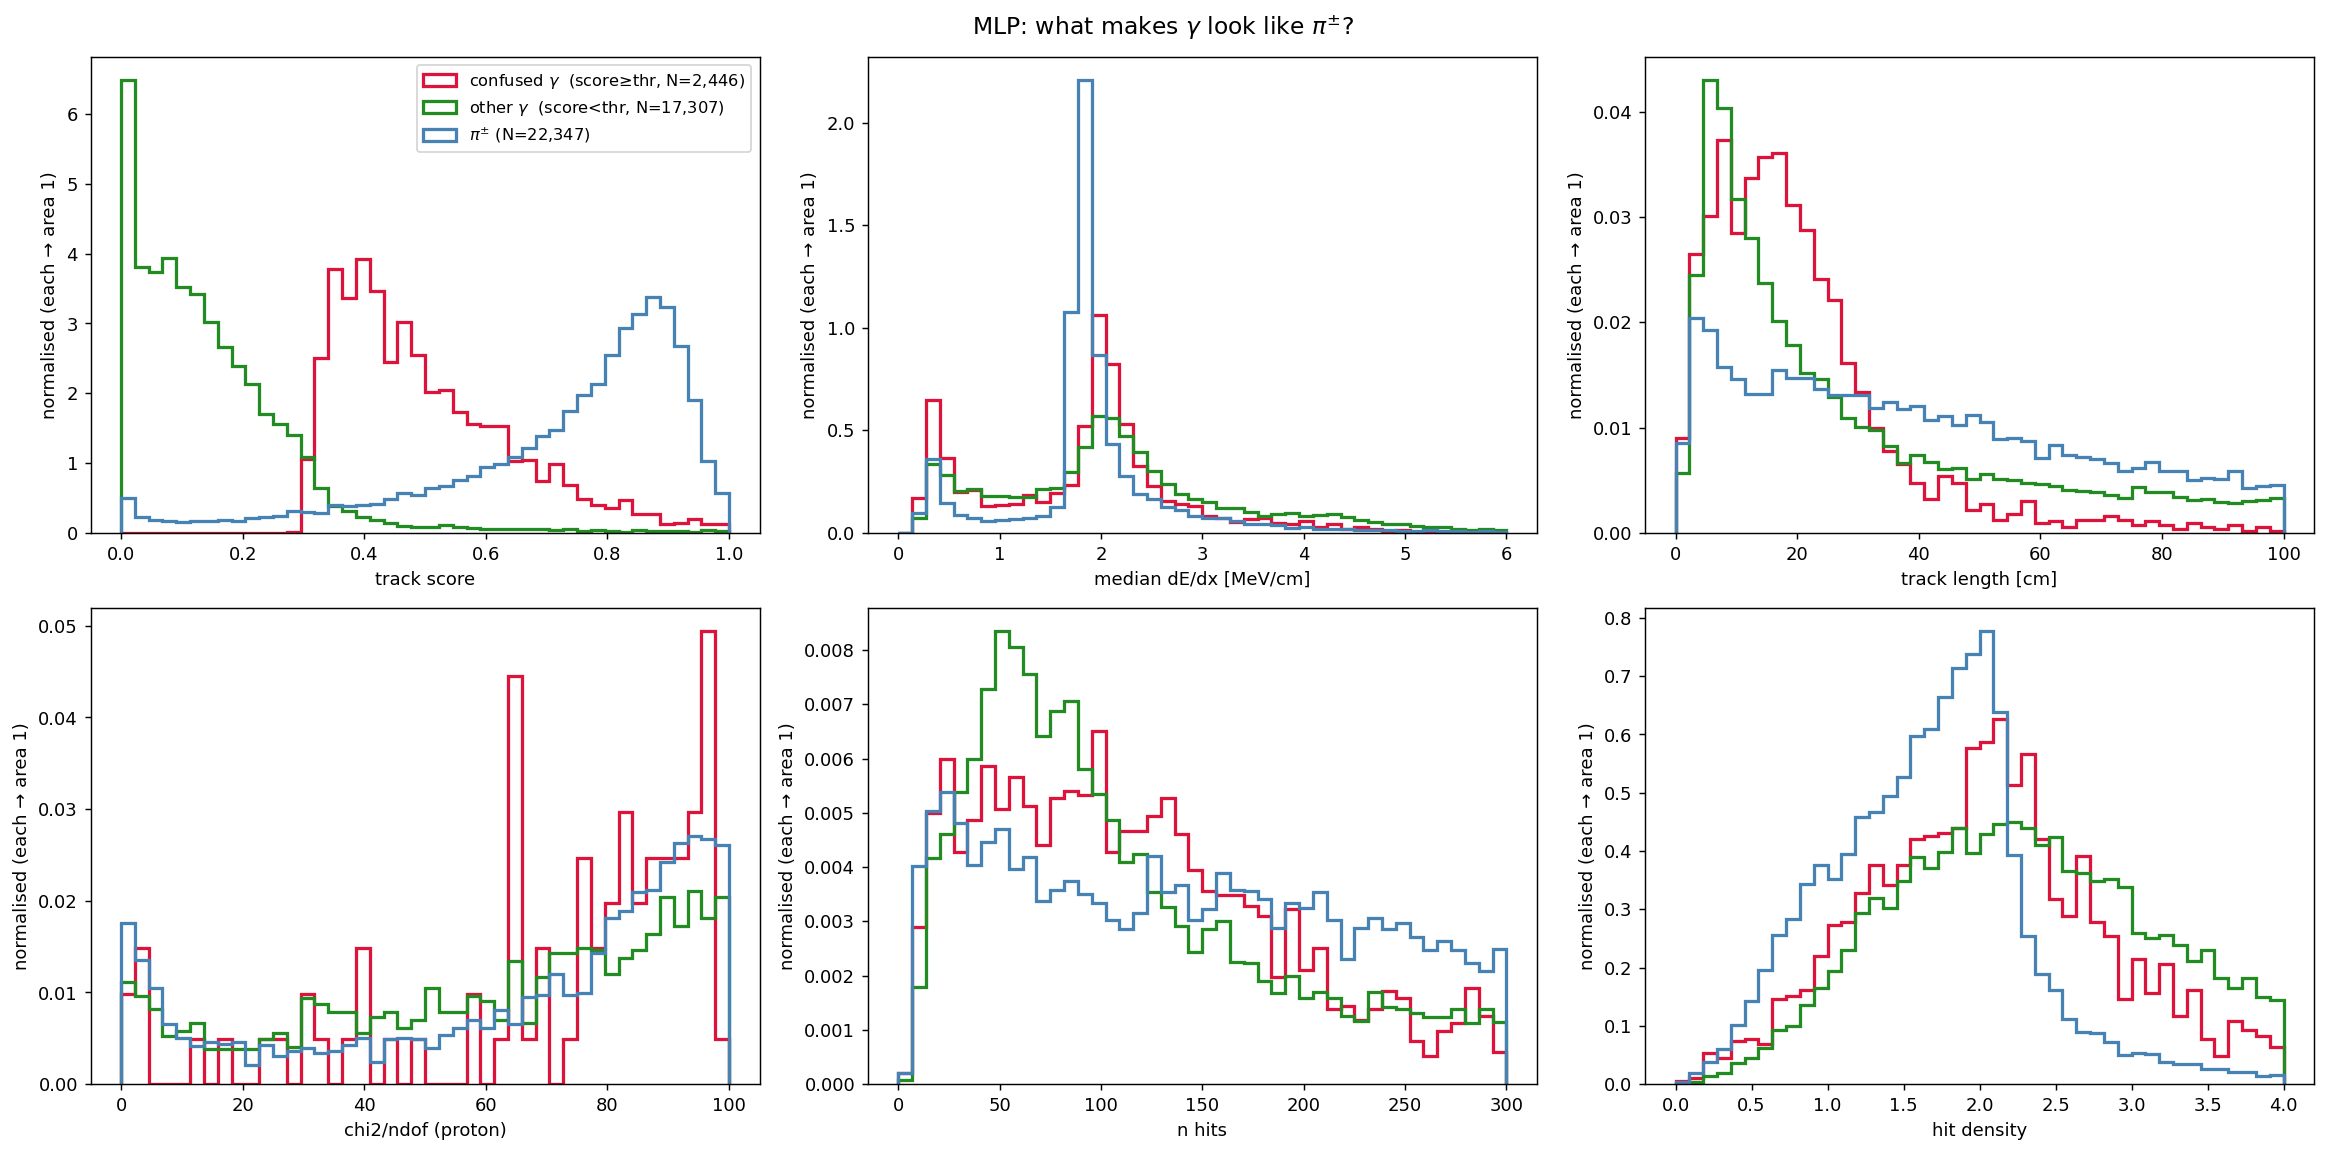

Saved /home/pemb7173/PDSP-pion-classification/plots/contamination-study/pion/confused_MLP_architecture_pion.pdf

Hybrid: 575 confused $\gamma$ (of 19,753) = 1.7% of the tagged sample


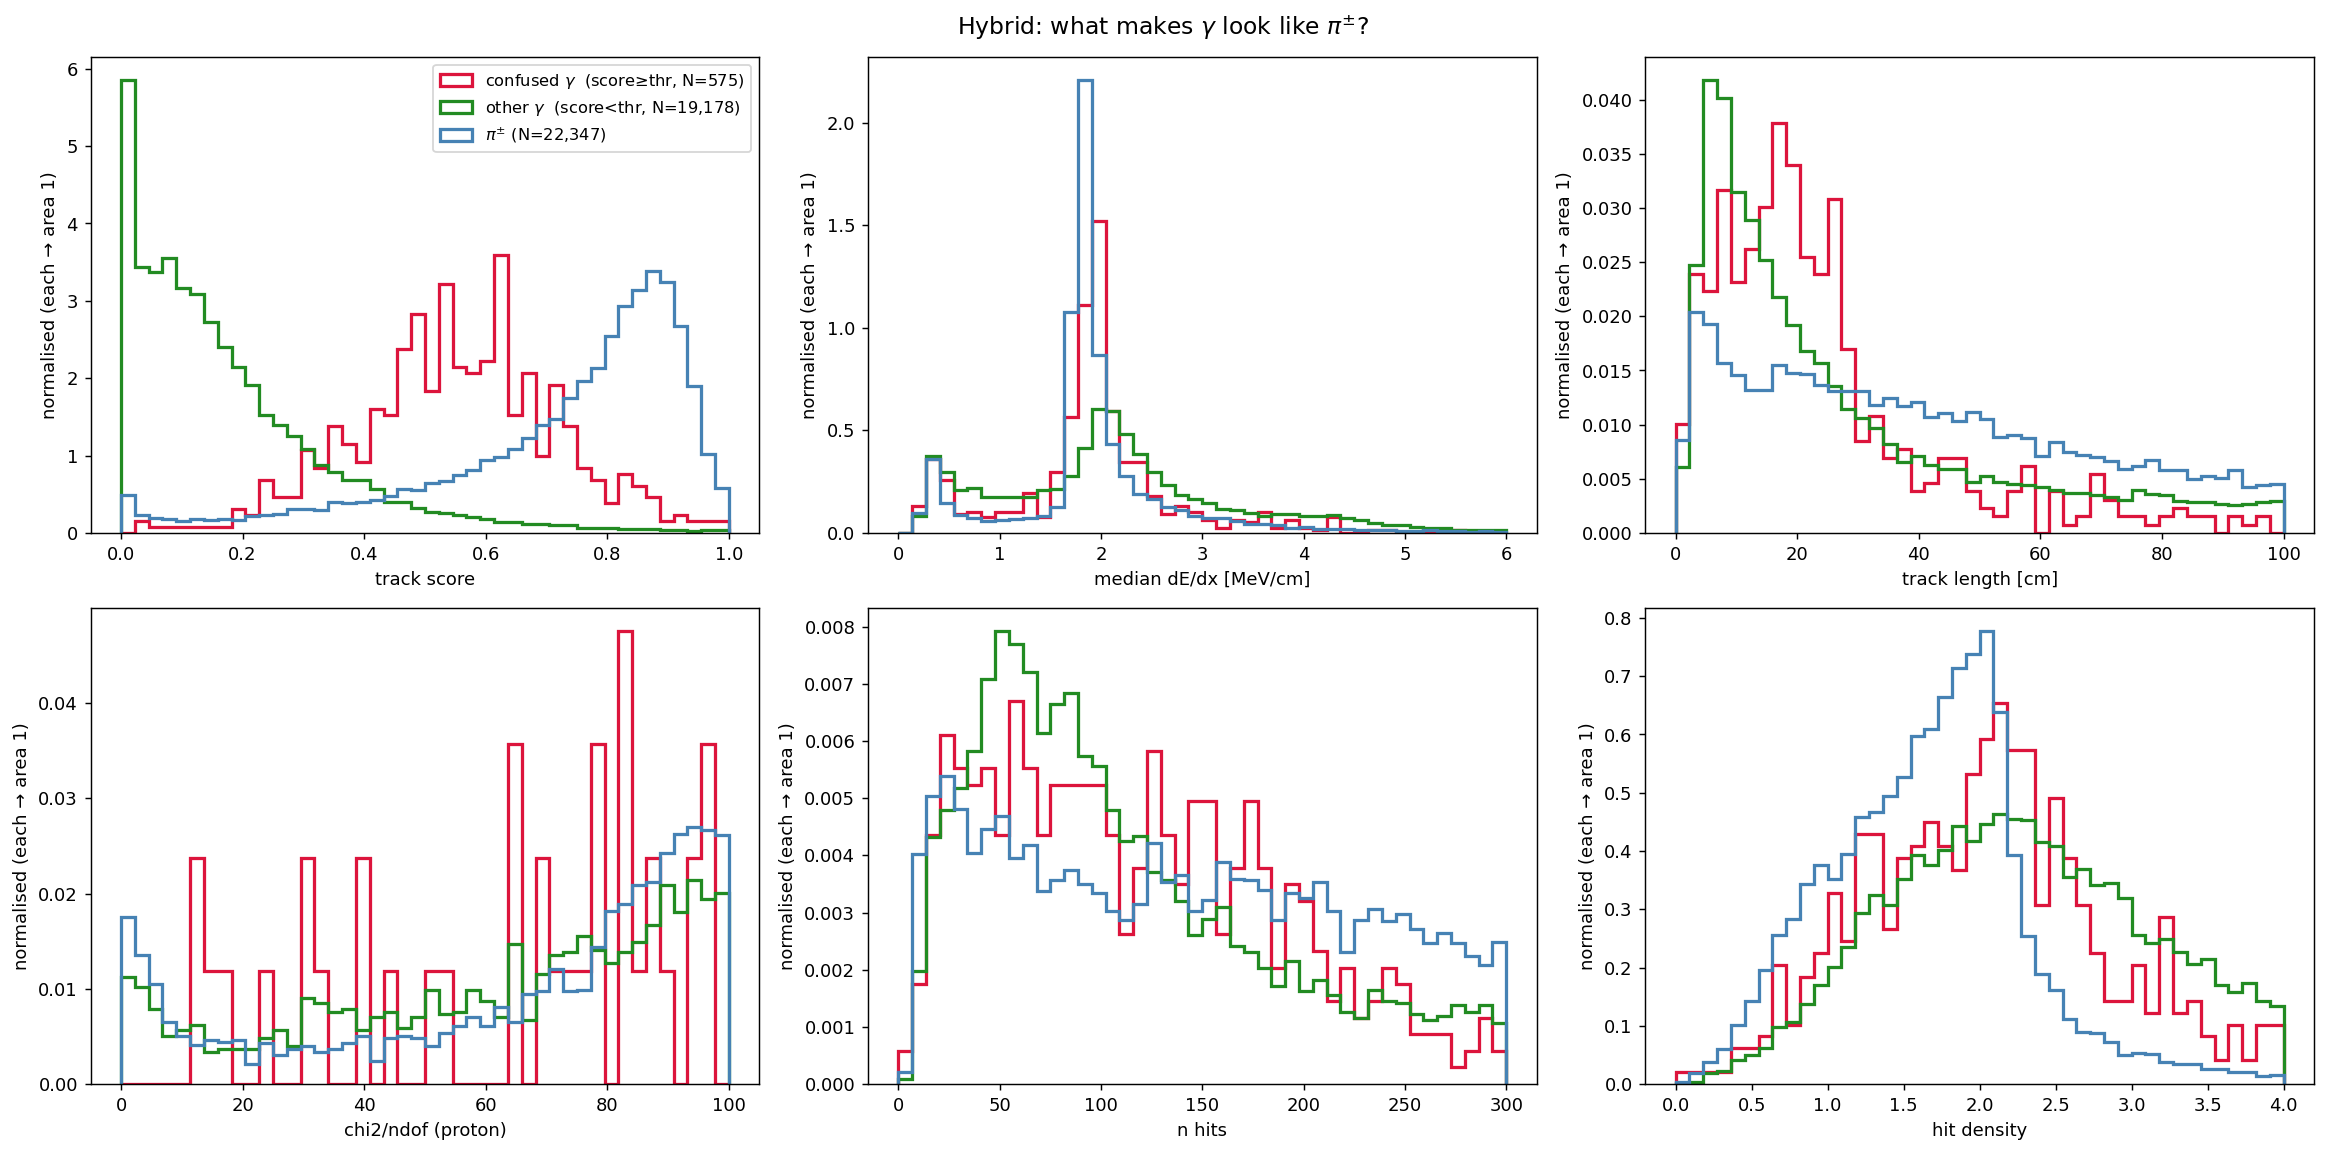

Saved /home/pemb7173/PDSP-pion-classification/plots/contamination-study/pion/confused_Hybrid_architecture_pion.pdf

model             confused   of total bkg   % of tagged
-------------------------------------------------------
CNN                  1,708         19,753          4.5%
MLP                  2,446         19,753          5.4%
Hybrid                 575         19,753          1.7%


In [6]:
# This notebook exists because of the mid-score peak in the data/MC comparison,
# which turned out to be photons the classifier was confusing for pions. The
# features comparison shows directly whether the provenance features reduced
# that population.
summary = {}

for MODEL_KEY, MODEL_PATH in MODELS.items():
    with open(MODEL_PATH, "rb") as f:
        d = pickle.load(f)
    probs = np.asarray(d["probs"])
    thr   = d["threshold"]

    bkg  = species == cfg['main_bkg']
    conf = bkg & (probs >= thr)
    good = bkg & (probs < thr)
    tagged = probs >= thr
    summary[MODEL_KEY] = (int(conf.sum()), int(bkg.sum()), int(tagged.sum()))

    print(f"{MODEL_KEY}: {conf.sum():,} confused {cfg['main_bkg']} "
          f"(of {bkg.sum():,}) = "
          f"{100*conf.sum()/max(tagged.sum(),1):.1f}% of the tagged sample")

    CATS = [(f"confused {cfg['main_bkg']}  (score≥thr, N={conf.sum():,})", conf, 'crimson'),
            (f"other {cfg['main_bkg']}  (score<thr, N={good.sum():,})",    good, 'forestgreen'),
            (f"{cfg['signal_name']} (N={is_signal.sum():,})",              is_signal, cfg['signal_colour'])]

    fig, ax = plt.subplots(2, 3, figsize=(18, 9), dpi=130)
    ax = ax.ravel()
    for j, (key, lab, rng) in enumerate(OBS_HD):
        v = OBSVALS[key]
        b = np.linspace(rng[0], rng[1], 45)
        for title, m, col in CATS:
            mm = m & np.isfinite(v)
            if mm.sum() < 10:
                continue
            ax[j].hist(v[mm], bins=b, histtype='step', density=True, lw=1.8,
                       color=col, label=title)
        ax[j].set_xlabel(lab)
        ax[j].set_ylabel('normalised (each → area 1)')
    ax[0].legend(fontsize=9)
    fig.suptitle(f"{MODEL_KEY}: what makes {cfg['main_bkg']} look like "
                 f"{cfg['signal_name']}?", fontsize=13)
    plt.tight_layout()
    out_path = PLOTS_DIR / (f"confused_{MODEL_KEY.replace(' ', '_')}_"
                            f"{COMPARISON}_{TARGET}.pdf")
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f"Saved {out_path}\n")

print(f"{'model':<16}{'confused':>10}{'of total bkg':>15}{'% of tagged':>14}")
print("-" * 55)
for k, (c, b, t) in summary.items():
    print(f"{k:<16}{c:>10,}{b:>15,}{100*c/max(t,1):>13.1f}%")

## Track-score cut trade-off (Hybrid)

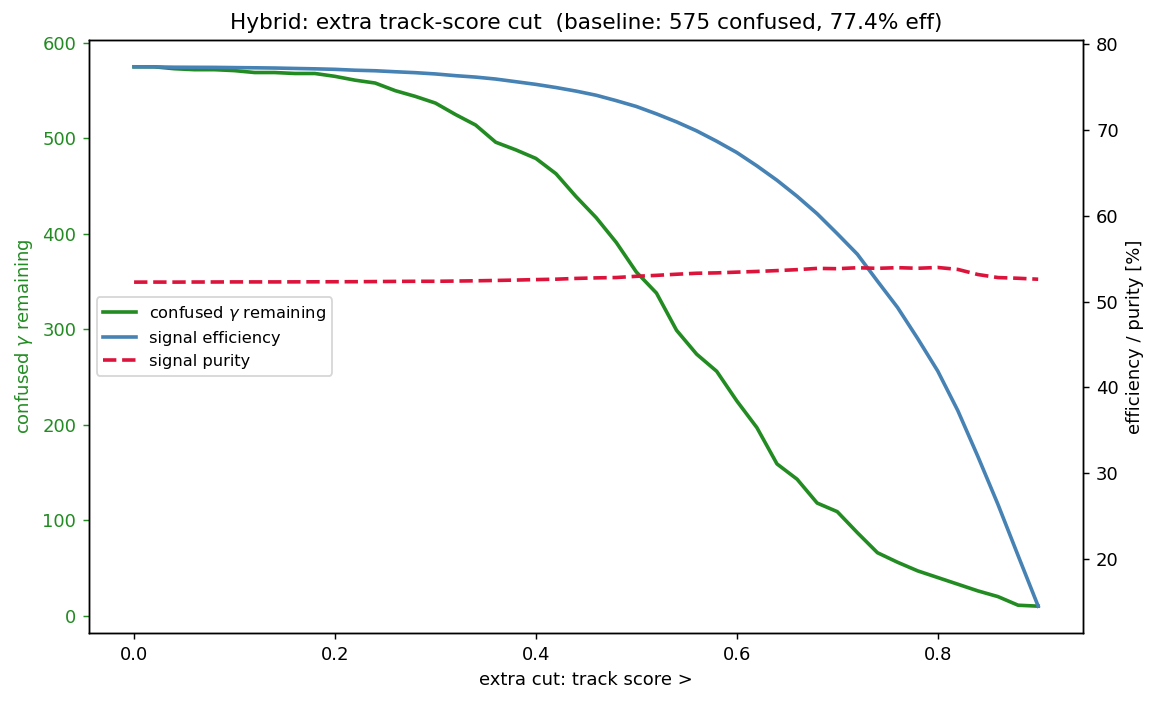

baseline (no extra cut):  575 confused $\gamma$ | 77.4% eff | 52.3% purity
 ts cut    confused    removed       eff   purity
   0.50         360        37%    72.7%    52.9%
   0.60         225        61%    67.4%    53.4%
   0.70         109        81%    57.9%    53.8%
   0.75          60        90%    51.0%    53.9%
   0.80          40        93%    41.9%    54.0%


In [7]:
# extra track-score cut trade-off for the Hybrid model
with open(MODELS[MODEL_KEY], "rb") as f:
    d = pickle.load(f)
probs = np.asarray(d["probs"]); thr = d["threshold"]
ts = OBSVALS["track_score"]

sig = is_signal
bkg = species == cfg['main_bkg']
tagged = probs >= thr
Nsig  = int(sig.sum())
conf0 = int((bkg & tagged).sum())
eff0  = (sig & tagged).sum() / Nsig

if cfg['ts_cut_keeps'] == 'above':
    cuts = np.linspace(0.0, 0.9, 46)
    keep_ts = lambda c: ts > c
    cut_lbl = 'extra cut: track score >'
else:
    cuts = np.linspace(1.0, 0.1, 46)
    keep_ts = lambda c: ts < c
    cut_lbl = 'extra cut: track score <'

conf = np.array([int((bkg & tagged & keep_ts(c)).sum()) for c in cuts])
eff  = np.array([(sig & tagged & keep_ts(c)).sum() / Nsig for c in cuts])
pur  = np.array([(sig & tagged & keep_ts(c)).sum() / max((tagged & keep_ts(c)).sum(), 1) for c in cuts])

fig, axL = plt.subplots(figsize=(9,5.5), dpi=130)
axR = axL.twinx()

l1, = axL.plot(cuts, conf, color='forestgreen', lw=2, label=f"confused {cfg['main_bkg']} remaining")
l2, = axR.plot(cuts, 100*eff, color='steelblue', lw=2, label='signal efficiency')
l3, = axR.plot(cuts, 100*pur, color='crimson',   lw=2, ls='--', label='signal purity')
axL.set_xlabel(cut_lbl); axL.set_ylabel(f"confused {cfg['main_bkg']} remaining", color='forestgreen')
axR.set_ylabel('efficiency / purity [%]'); axL.tick_params(axis='y', colors='forestgreen')
axL.set_title(f"{MODEL_KEY}: extra track-score cut  (baseline: {conf0:,} confused, {100*eff0:.1f}% eff)")

axL.legend(handles=[l1,l2,l3], fontsize=9, loc='center left')
plt.tight_layout()
out_path = PLOTS_DIR / f"trackscore_cut_tradeoff_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()

print(f"baseline (no extra cut):  {conf0:,} confused {cfg['main_bkg']} | "
      f"{100*eff0:.1f}% eff | "
      f"{100*(sig & tagged).sum()/max(tagged.sum(), 1):.1f}% purity")

SUMMARY_CUTS = ([0.5, 0.6, 0.7, 0.75, 0.8] if cfg['ts_cut_keeps'] == 'above'
                else [0.5, 0.4, 0.3, 0.25, 0.2])

print(f"{'ts cut':>7}{'confused':>12}{'removed':>11}{'eff':>10}{'purity':>9}")
for c in SUMMARY_CUTS:
    keep = tagged & keep_ts(c)
    cg = int((bkg & keep).sum())
    pe = 100 * (sig & keep).sum() / Nsig
    pu = 100 * (sig & keep).sum() / max(keep.sum(), 1)
    print(f"{c:>7.2f}{cg:>12,}{100*(1 - cg/max(conf0, 1)):>10.0f}%{pe:>8.1f}%{pu:>8.1f}%")